<a href="https://colab.research.google.com/github/sarvesvy/spider_Task_2_submissions/blob/main/task_2_level_2_spml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import urllib.request
import zipfile

def download_jena_climate():
    # The official dataset URL used in standard ML tutorials
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
    zip_path = "jena_climate_2009_2016.csv.zip"
    csv_path = "jena_climate_2009_2016.csv"

    # Check if you already have it to avoid downloading 40MB again
    if os.path.exists(csv_path):
        print(f"Dataset already exists at: {os.path.abspath(csv_path)}")
        return

    print("Downloading Jena Climate dataset (this may take a minute or two)...")
    urllib.request.urlretrieve(url, zip_path)

    print("Download complete. Extracting CSV...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")

    print("Cleaning up temporary zip file...")
    os.remove(zip_path)

    print(f"\nSuccess! '{csv_path}' is now download")


# Execute the download
download_jena_climate()

Download complete. Extracting CSV...
Cleaning up temporary zip file...

Success! 'jena_climate_2009_2016.csv' is now download


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error




In [21]:
class LSTMCell(nn.Module):
  def __init__(self,input_size,hidden_size):
    super(LSTMCell,self).__init__()
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.W=nn.Linear(input_size + hidden_size,4*hidden_size)

  def forward(self, x_t, hidden):
    h_prev , c_prev = hidden
    combined =torch.cat((x_t, h_prev),dim=1)
    gates =self.W(combined)
    f_gate,i_gate,c_gate,o_gate =gates.chunk(4, 1)

    f_t =torch.sigmoid(f_gate)
    i_t =torch.sigmoid(i_gate)
    c_tilde =torch.tanh(c_gate)
    o_t =torch.sigmoid(o_gate)
    c_t = f_t * c_prev + i_t * c_tilde
    h_t = o_t * torch.tanh(c_t)

    return h_t, c_t


class ScratchLSTM(nn.Module):
    def __init__(self,input_size,hidden_size,num_layers=1):
        super(ScratchLSTM,self).__init__()
        self.hidden_size =hidden_size
        self.num_layers =num_layers

        self.cells =nn.ModuleList([
            LSTMCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])

    def forward(self, x):
        batch_size,seq_len, _ = x.size()
        device = x.device
        h =[torch.zeros(batch_size, self.hidden_size, device=device) for _ in range(self.num_layers)]
        c =[torch.zeros(batch_size, self.hidden_size, device=device) for _ in range(self.num_layers)]

        for t in range(seq_len):
            x_t = x[:, t, :]
            for layer in range(self.num_layers):
                h[layer], c[layer] = self.cells[layer](x_t, (h[layer], c[layer]))
                x_t = h[layer]
        return h[-1]
class JenaWeatherForecaster(nn.Module):
    def __init__(self, input_features, hidden_size=64, num_layers=2):
        super(JenaWeatherForecaster, self).__init__()
        self.lstm = ScratchLSTM(input_features, hidden_size, num_layers)
        self.fc = nn.Linear(hidden_size, 12) # Predicts 12 hours out

    def forward(self, x):
        return self.fc(self.lstm(x)) #predictions

In [16]:
#data preperation
class WeatherDataset(Dataset):
    def __init__(self, history_size=72, target_size=12, is_train=True):
        self.history_size = history_size
        self.target_size = target_size

        if os.path.exists('jena_climate_2009_2016.csv'):
            print("Loading real Jena Climate dataset...")
            df =pd.read_csv('jena_climate_2009_2016.csv').drop('Date Time', axis=1)
            self.target_idx = list(df.columns).index("T (degC)")
            data =df.values
        else:
            print("Jena CSV not found. Generating synthetic weather data for demonstration...")
            # Generate 5000 hours of synthetic data: sine wave (daily temps) + random noise
            time = np.arange(5000)
            temps = 15 + 10 * np.sin(2 * np.pi * time / 24) + np.random.normal(0, 1, 5000)
            pressure = 1013 + 5 * np.cos(2 * np.pi * time / 24) + np.random.normal(0, 2, 5000)
            data = np.column_stack((temps, pressure))
            self.target_idx = 0

        # Split Train/Val (80/20)
        split_idx =int(len(data) * 0.8)
        self.data_raw =data[:split_idx] if is_train else data[split_idx:]

        # Fit scaler ONLY on training data to prevent data leakage
        self.scaler_X =StandardScaler()
        self.scaler_y =StandardScaler()

        self.data_scaled = self.scaler_X.fit_transform(self.data_raw)
        self.scaler_y.fit(self.data_raw[:, self.target_idx].reshape(-1, 1))

    def __len__(self):
        return len(self.data_scaled) - self.history_size - self.target_size

    def __getitem__(self, idx):
        history =self.data_scaled[idx : idx + self.history_size]
        target =self.data_scaled[idx + self.history_size : idx + self.history_size + self.target_size, self.target_idx]
        return torch.tensor(history, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

In [22]:
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Data
train_dataset =WeatherDataset(is_train=True)
val_dataset =WeatherDataset(is_train=False)
train_loader =DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader =DataLoader(val_dataset, batch_size=64, shuffle=False)

# Initialize Model
num_features = train_dataset.data_scaled.shape[1]
model = JenaWeatherForecaster(input_features=num_features, hidden_size=64, num_layers=2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 10
train_losses, val_losses = [], []

print("Starting training---------------")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch , y_batch in train_loader:
        X_batch , y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch , y_batch in val_loader:
            X_batch , y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))
    print(f"Epoch {epoch+1}/{epochs} | Train Loss (MSE): {train_losses[-1]:.4f} | Val Loss (MSE): {val_losses[-1]:.4f}")
print('done--------------------------------')

Loading real Jena Climate dataset...
Loading real Jena Climate dataset...
Starting training---------------
Epoch 1/10 | Train Loss (MSE): 0.0156 | Val Loss (MSE): 0.0134
Epoch 2/10 | Train Loss (MSE): 0.0091 | Val Loss (MSE): 0.0113
Epoch 3/10 | Train Loss (MSE): 0.0084 | Val Loss (MSE): 0.0114
Epoch 4/10 | Train Loss (MSE): 0.0080 | Val Loss (MSE): 0.0120
Epoch 5/10 | Train Loss (MSE): 0.0077 | Val Loss (MSE): 0.0110
Epoch 6/10 | Train Loss (MSE): 0.0074 | Val Loss (MSE): 0.0104
Epoch 7/10 | Train Loss (MSE): 0.0072 | Val Loss (MSE): 0.0109
Epoch 8/10 | Train Loss (MSE): 0.0070 | Val Loss (MSE): 0.0109
Epoch 9/10 | Train Loss (MSE): 0.0068 | Val Loss (MSE): 0.0108
Epoch 10/10 | Train Loss (MSE): 0.0065 | Val Loss (MSE): 0.0106



=== FINAL FORECAST METRICS ===
Mean Absolute Error (MAE): 0.60°C (Average error in degrees)
Mean Squared Error (MSE):  0.75
[Saved] loss_curves.png
[Saved] forecast_example.png


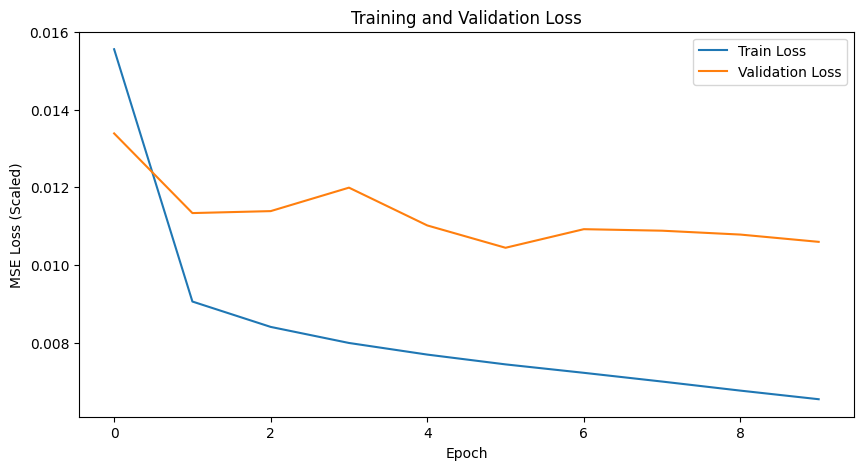

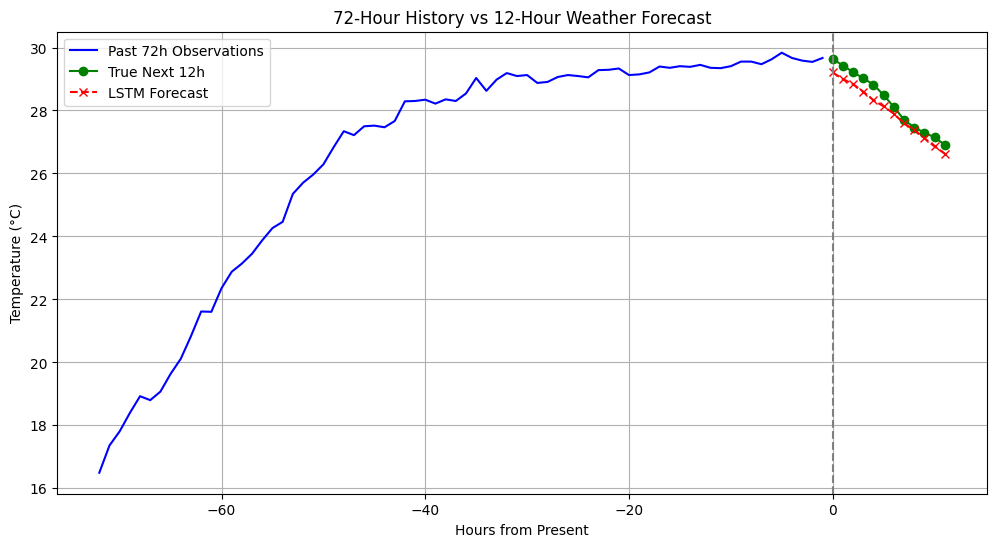

In [23]:
#output
all_preds, all_targets, all_histories = [], [], []
model.eval()
with torch.no_grad():
    for X_batch , y_batch in val_loader:
        X_batch , y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())
        # Save just the temperature feature of the history for plotting
        all_histories.append(X_batch[:, :, train_dataset.target_idx].cpu().numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)
all_histories = np.vstack(all_histories)

# Inverse transform to get actual degrees Celsius
preds_celsius = train_dataset.scaler_y.inverse_transform(all_preds)
targets_celsius = train_dataset.scaler_y.inverse_transform(all_targets)
histories_celsius = train_dataset.scaler_y.inverse_transform(all_histories)

# Output Regression Metrics
mae = mean_absolute_error(targets_celsius, preds_celsius)
mse = mean_squared_error(targets_celsius, preds_celsius)

print("\n=== FINAL FORECAST METRICS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}°C (Average error in degrees)")
print(f"Mean Squared Error (MSE):  {mse:.2f}")

# PLOT 1: Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (Scaled)')
plt.legend()
plt.savefig('loss_curves.png')
print("[Saved] loss_curves.png")

# PLOT 2: Forecast Example Visualization
plt.figure(figsize=(12, 6))
# Select a random sequence from the validation set
sample_idx = np.random.randint(0, len(preds_celsius))

past_time = np.arange(-72, 0)
future_time = np.arange(0, 12)

plt.plot(past_time, histories_celsius[sample_idx], label='Past 72h Observations', color='blue')
plt.plot(future_time, targets_celsius[sample_idx], label='True Next 12h', color='green', marker='o')
plt.plot(future_time, preds_celsius[sample_idx], label='LSTM Forecast', color='red', linestyle='--', marker='x')

plt.title('72-Hour History vs 12-Hour Weather Forecast')
plt.xlabel('Hours from Present')
plt.ylabel('Temperature (°C)')
plt.axvline(x=0, color='gray', linestyle='--')
plt.legend()
plt.grid(True)
plt.savefig('forecast_example.png')
print("[Saved] forecast_example.png")